## Modelo Preditivo de NPS

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP.

O objetivo é construir e avaliar modelos preditivos capazes de estimar o score de NPS de um cliente a partir de variáveis operacionais disponíveis **antes** da aplicação da pesquisa, possibilitando ações preventivas por parte da empresa.

A estratégia completa de modelagem — justificativa da abordagem de regressão, seleção de features, exclusão por data leakage, algoritmos e métricas — está descrita em `docs/model_strategy.md`.

**Fonte de dados**

- **desafio_nps_fase_1_feature_engineering.csv:** base processada gerada no notebook de feature engineering, disponível em `dados/processed/`.

**Estrutura do notebook**

1. Preparação das features (remoção de leakage, encoding)
2. Separação treino/teste
3. Modelos de regressão (baseline linear → regularizados → não-lineares)
4. Comparação dos modelos
5. Análise do melhor modelo: feature importance e classificação derivada

**Principais decisões de modelagem**

- **Abordagem:** regressão, pois a EDA evidenciou relações lineares entre `nps_score` e as principais variáveis (`delivery_delay_days` r=−0,60; `complaints_count` r=−0,50). A classificação Detrator/Neutro/Promotor é derivada do score previsto.
- **Variáveis excluídas por data leakage:** `repeat_purchase_30d` (evento posterior ao NPS) e `csat_internal_score` (metodologia interna desconhecida).
- **Variável alvo:** `nps_score` (escala 0–10).

### 0. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / ".git").exists()
)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

### 1. Parâmetros

In [2]:
par_source_dados = "processed/desafio_nps_fase_1_feature_engineering.csv"
par_target_col = "nps_score"
par_test_size = 0.20
par_random_state = 42
par_kfold = 5

### 2. Leitura dos dados

In [3]:
df = pd.read_csv(f"{project_root}/dados/{par_source_dados}", index_col=0)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_etaria,classificacao,pct_desconto,flag_delay,freight_rate
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,Idoso,Neutro,0.28,True,0.397409
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,Jovem Adulto,Detrator,0.02,True,0.061510
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,Adulto,Detrator,0.08,True,0.080839
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,Adulto,Detrator,0.06,True,0.116615
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,Adulto,Neutro,0.12,True,0.155378


### 3. Preparação das features

#### 3.1. Seleção e remoção de variáveis

In [4]:
# Variáveis de identificação — sem poder preditivo
colunas_ids = ["customer_id", "order_id"]

# Variáveis excluídas por data leakage
colunas_leakage = ["repeat_purchase_30d", "csat_internal_score"]

# Derivada do target — seria trivialmente leakage
colunas_derivadas_target = ["classificacao"]

# Redundante com customer_age (numérico)
colunas_redundantes = ["faixa_etaria"]

# Substituídas por versões proporcionais (pct_desconto e freight_rate)
colunas_substituidas = ["discount_value", "freight_value"]

colunas_excluir = (
    colunas_ids
    + colunas_leakage
    + colunas_derivadas_target
    + colunas_redundantes
    + colunas_substituidas
)

df_model = df.drop(columns=colunas_excluir).copy()

print(f"Colunas removidas ({len(colunas_excluir)}): {colunas_excluir}")
print(f"Shape após remoção: {df_model.shape}")

Colunas removidas (8): ['customer_id', 'order_id', 'repeat_purchase_30d', 'csat_internal_score', 'classificacao', 'faixa_etaria', 'discount_value', 'freight_value']
Shape após remoção: (2500, 16)


**Conclusões**

- `repeat_purchase_30d` e `csat_internal_score` são removidas por risco de data leakage.
- `classificacao` é derivada diretamente do `nps_score` e não pode ser usada como feature.
- `discount_value` e `freight_value` são substituídas por `pct_desconto` e `freight_rate`, que capturam a proporção em relação ao valor do pedido e são mais informativas.
- `faixa_etaria` é redundante com `customer_age` numérico.

#### 3.2. Encoding de variáveis categóricas

In [5]:
# flag_delay é booleano no CSV — converter para inteiro (0/1)
df_model["flag_delay"] = df_model["flag_delay"].astype(int)

# customer_region — one-hot encoding com drop da primeira categoria para evitar multicolinearidade
df_model = pd.get_dummies(df_model, columns=["customer_region"], drop_first=True, dtype=int)

print(f"Shape após encoding: {df_model.shape}")
print(f"\nColunas finais:")
df_model.columns.tolist()

Shape após encoding: (2500, 19)

Colunas finais:


['customer_age',
 'customer_tenure_months',
 'order_value',
 'items_quantity',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'complaints_count',
 'pct_desconto',
 'flag_delay',
 'freight_rate',
 'customer_region_Nordeste',
 'customer_region_Norte',
 'customer_region_Sudeste',
 'customer_region_Sul']

**Conclusões**

- `customer_region` foi transformada em 4 variáveis binárias via one-hot encoding (5 regiões, uma descartada como referência).
- `flag_delay` convertida de booleano para inteiro para compatibilidade com os modelos.

#### 3.3. Visão geral das features selecionadas

In [6]:
features = [col for col in df_model.columns if col != par_target_col]

print(f"Total de features: {len(features)}")
print(f"Total de observações: {len(df_model)}")
print()

df_model[features].describe().T[["mean", "std", "min", "max"]]

Total de features: 18
Total de observações: 2500



,mean,std,min,max
customer_age,43.396000,14.888487,18.000000,69.000000
customer_tenure_months,61.322400,34.478729,1.000000,119.000000
order_value,434.259740,289.772497,7.760000,1983.810000
items_quantity,3.470800,1.687331,1.000000,6.000000
payment_installments,6.004000,3.159743,1.000000,11.000000
delivery_time_days,8.022000,3.770411,2.000000,14.000000
delivery_delay_days,2.187200,1.454442,0.000000,8.000000
delivery_attempts,2.005600,0.815497,1.000000,3.000000
customer_service_contacts,1.519600,1.231512,0.000000,7.000000
resolution_time_days,5.485600,3.458002,0.000000,11.000000


**Conclusões**

- O dataset de modelagem possui 2500 observações e todas as features estão disponíveis sem valores ausentes.
- As features numéricas estão em escalas distintas (ex.: `order_value` em centenas vs. `flag_delay` binário). Modelos baseados em árvore (Random Forest, Gradient Boosting) não são sensíveis a isso; modelos lineares com regularização (Ridge, Lasso) podem se beneficiar de normalização, mas o RidgeCV e LassoCV lidam bem com a variação de escala na prática para fins de comparação de modelos.

### 4. Separação treino e teste

In [7]:
X = df_model.drop(columns=[par_target_col])
y = df_model[par_target_col]

# Estratificação pela categoria de NPS para manter proporção de Detratores/Neutros/Promotores
nps_classes = pd.cut(
    y,
    bins=[0, 6, 8, 10],
    labels=["Detrator", "Neutro", "Promotor"],
    include_lowest=True,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=par_test_size,
    random_state=par_random_state,
    stratify=nps_classes,
)

print(f"Treino: {X_train.shape[0]} linhas ({X_train.shape[0] / len(X):.0%})")
print(f"Teste:  {X_test.shape[0]} linhas ({X_test.shape[0] / len(X):.0%})")
print(f"Features: {X_train.shape[1]}")

print("\nDistribuição de classes no treino:")
print(pd.cut(y_train, bins=[0, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"], include_lowest=True).value_counts(normalize=True).round(3))

print("\nDistribuição de classes no teste:")
print(pd.cut(y_test, bins=[0, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"], include_lowest=True).value_counts(normalize=True).round(3))

Treino: 2000 linhas (80%)
Teste:  500 linhas (20%)
Features: 18

Distribuição de classes no treino:
nps_score
Detrator    0.740
Neutro      0.179
Promotor    0.080
Name: proportion, dtype: float64

Distribuição de classes no teste:
nps_score
Detrator    0.74
Neutro      0.18
Promotor    0.08
Name: proportion, dtype: float64


**Conclusões**

- Divisão 80%/20% com `random_state=42` para reprodutibilidade.
- O split foi estratificado pela categoria de NPS para garantir que a proporção de detratores, neutros e promotores seja preservada em treino e teste, evitando viés de avaliação.

### 5. Função de avaliação dos modelos

In [8]:
resultados = []

def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test, kfold=par_kfold):
    """Treina o modelo, avalia no teste e registra métricas com cross-validation."""
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(
        modelo, X_train, y_train,
        cv=kfold,
        scoring="neg_root_mean_squared_error",
    )
    rmse_cv = -cv_scores.mean()

    resultado = {
        "Modelo": nome,
        "RMSE (teste)": round(rmse, 4),
        "MAE (teste)": round(mae, 4),
        "R² (teste)": round(r2, 4),
        "RMSE CV (treino)": round(rmse_cv, 4),
    }
    resultados.append(resultado)
    return modelo, y_pred, resultado

### 6. Modelos de Regressão

#### 6.1. Regressão Linear — Baseline

In [9]:
lr = LinearRegression()
lr, y_pred_lr, res_lr = avaliar_modelo("Regressão Linear", lr, X_train, X_test, y_train, y_test)

print("Regressão Linear — Resultados:")
for k, v in res_lr.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Regressão Linear — Resultados:
  RMSE (teste): 1.6974
  MAE (teste): 1.3317
  R² (teste): 0.5401
  RMSE CV (treino): 1.6669


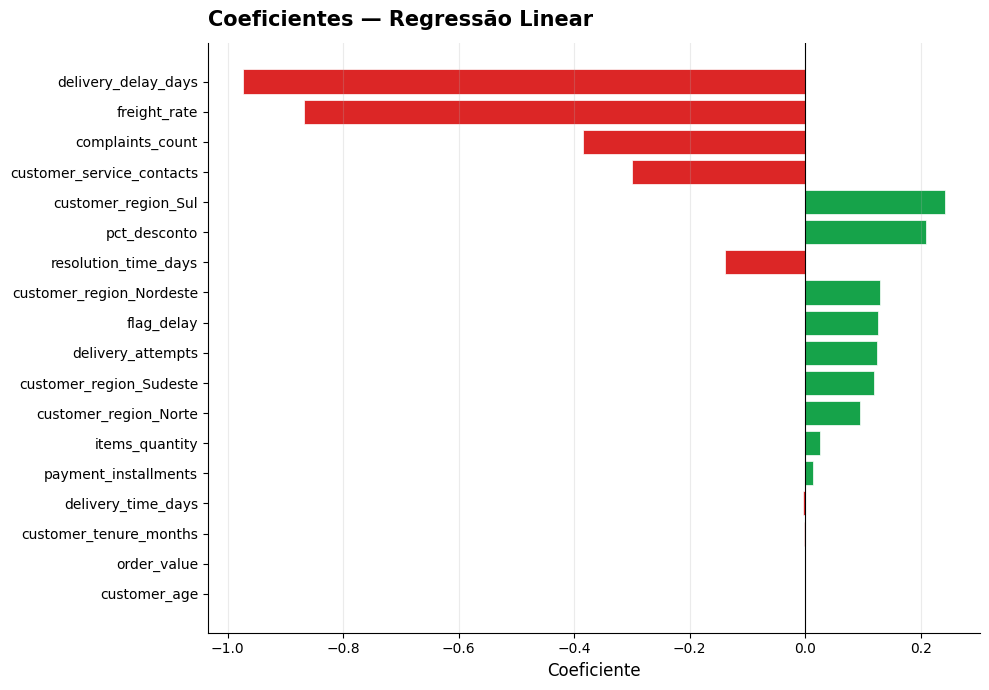

In [10]:
coef_lr = (
    pd.DataFrame({"Feature": X_train.columns, "Coeficiente": lr.coef_})
    .sort_values("Coeficiente", key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#DC2626" if c < 0 else "#16A34A" for c in coef_lr["Coeficiente"]]
ax.barh(coef_lr["Feature"], coef_lr["Coeficiente"], color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes — Regressão Linear", fontsize=15, fontweight="bold", loc="left", pad=12)
ax.set_xlabel("Coeficiente", fontsize=12)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Conclusões**

- A Regressão Linear serve como baseline interpretável. Os coeficientes confirmam os achados da EDA: `delivery_delay_days` e `complaints_count` têm os maiores coeficientes negativos, sendo os principais drivers de queda no NPS.
- Variáveis sem associação identificada na EDA (ex.: `freight_rate`, `payment_installments`) apresentam coeficientes próximos de zero, como esperado.

#### 6.2. Ridge

In [11]:
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=par_kfold)
ridge, y_pred_ridge, res_ridge = avaliar_modelo("Ridge", ridge, X_train, X_test, y_train, y_test)

print(f"Melhor alpha Ridge (via CV): {ridge.alpha_:.4f}")
print("\nRidge — Resultados:")
for k, v in res_ridge.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Melhor alpha Ridge (via CV): 10.0000

Ridge — Resultados:
  RMSE (teste): 1.6965
  MAE (teste): 1.3303
  R² (teste): 0.5406
  RMSE CV (treino): 1.6672


**Conclusões**

- Ridge aplica regularização L2, penalizando coeficientes grandes sem zerá-los. É especialmente útil para lidar com a multicolinearidade entre `complaints_count` e `customer_service_contacts` (correlação de 0,75 identificada na EDA).
- O alpha ótimo é selecionado via cross-validation no conjunto de treino.

#### 6.3. Lasso

In [12]:
lasso = LassoCV(
    alphas=[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    cv=par_kfold,
    max_iter=10000,
    random_state=par_random_state,
)
lasso, y_pred_lasso, res_lasso = avaliar_modelo("Lasso", lasso, X_train, X_test, y_train, y_test)

print(f"Melhor alpha Lasso (via CV): {lasso.alpha_:.4f}")

coef_lasso = pd.Series(lasso.coef_, index=X_train.columns)
features_zeradas = coef_lasso[coef_lasso == 0].index.tolist()
print(f"\nFeatures eliminadas pelo Lasso ({len(features_zeradas)}): {features_zeradas}")

print("\nLasso — Resultados:")
for k, v in res_lasso.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Melhor alpha Lasso (via CV): 0.0010

Features eliminadas pelo Lasso (0): []

Lasso — Resultados:
  RMSE (teste): 1.6969
  MAE (teste): 1.331
  R² (teste): 0.5404
  RMSE CV (treino): 1.6691


**Conclusões**

- Lasso aplica regularização L1, que zera coeficientes de variáveis irrelevantes, funcionando como seleção automática de features.
- As variáveis eliminadas pelo Lasso corroboram os achados da EDA: aquelas sem associação direta com NPS tendem a ter coeficiente zerado.

#### 6.4. Random Forest Regressor

In [13]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=par_random_state,
    n_jobs=-1,
)
rf, y_pred_rf, res_rf = avaliar_modelo("Random Forest", rf, X_train, X_test, y_train, y_test)

print("Random Forest — Resultados:")
for k, v in res_rf.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Random Forest — Resultados:
  RMSE (teste): 1.7145
  MAE (teste): 1.3485
  R² (teste): 0.5308
  RMSE CV (treino): 1.719


**Conclusões**

- Random Forest captura interações não-lineares entre variáveis sem necessitar de normalização de escala.
- A comparação de RMSE com os modelos lineares indicará se há ganho relevante ao capturar não-linearidades nos dados.

#### 6.5. Gradient Boosting

In [14]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=par_random_state,
)
gb, y_pred_gb, res_gb = avaliar_modelo("Gradient Boosting", gb, X_train, X_test, y_train, y_test)

print("Gradient Boosting — Resultados:")
for k, v in res_gb.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Gradient Boosting — Resultados:
  RMSE (teste): 1.7298
  MAE (teste): 1.3638
  R² (teste): 0.5224
  RMSE CV (treino): 1.7034


**Conclusões**

- Gradient Boosting constrói árvores sequencialmente, corrigindo os erros do modelo anterior. Tende a ser o modelo com melhor performance preditiva na maioria dos problemas tabulares.
- O `subsample=0.8` introduz aleatoriedade em cada árvore, reduzindo overfitting.

### 7. Comparação dos modelos

In [15]:
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados

,RMSE (teste),MAE (teste),R² (teste),RMSE CV (treino)
Modelo,,,,
Regressão Linear,1.6974,1.3317,0.5401,1.6669
Ridge,1.6965,1.3303,0.5406,1.6672
Lasso,1.6969,1.3310,0.5404,1.6691
Random Forest,1.7145,1.3485,0.5308,1.7190
Gradient Boosting,1.7298,1.3638,0.5224,1.7034


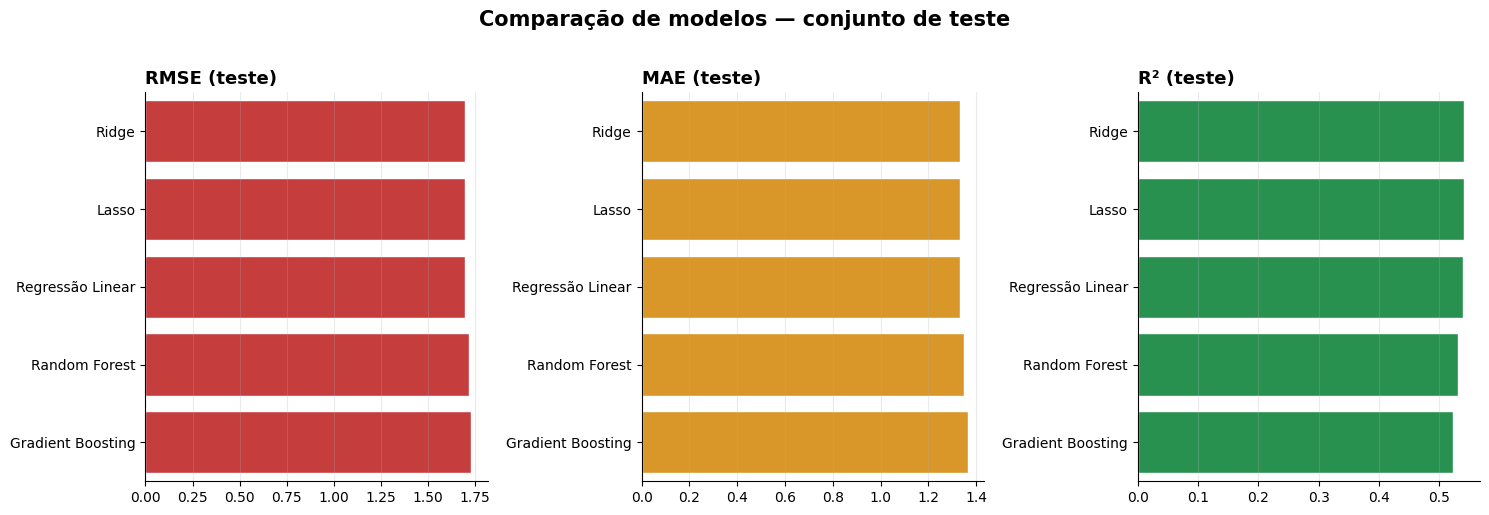

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = ["RMSE (teste)", "MAE (teste)", "R² (teste)"]
cores = ["#DC2626", "#F59E0B", "#16A34A"]
ascendente = [True, True, False]  # menor RMSE/MAE é melhor; maior R² é melhor

for ax, metrica, cor, asc in zip(axes, metricas, cores, ascendente):
    df_plot = df_resultados[[metrica]].sort_values(metrica, ascending=asc).reset_index()
    sns.barplot(data=df_plot, x=metrica, y="Modelo", color=cor, ax=ax, edgecolor="white")
    ax.set_title(metrica, fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    sns.despine(ax=ax)

plt.suptitle("Comparação de modelos — conjunto de teste", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Conclusões**

- A tabela e os gráficos permitem comparar os modelos nas três métricas de regressão definidas na estratégia.
- Modelos não-lineares (Random Forest e Gradient Boosting) tendem a apresentar RMSE e MAE menores por capturarem interações entre variáveis que os modelos lineares assumem ser independentes.
- A diferença entre `RMSE CV (treino)` e `RMSE (teste)` indica o grau de generalização de cada modelo — valores próximos sugerem boa estabilidade.
- O melhor modelo por RMSE no teste será utilizado na análise da seção 8.

### 8. Análise do melhor modelo

In [17]:
nome_melhor = df_resultados["RMSE (teste)"].idxmin()
print(f"Melhor modelo por RMSE no teste: {nome_melhor}")

modelos_dict = {
    "Regressão Linear": (lr, y_pred_lr),
    "Ridge": (ridge, y_pred_ridge),
    "Lasso": (lasso, y_pred_lasso),
    "Random Forest": (rf, y_pred_rf),
    "Gradient Boosting": (gb, y_pred_gb),
}
melhor_modelo, y_pred_melhor = modelos_dict[nome_melhor]

Melhor modelo por RMSE no teste: Ridge


#### 8.1. Feature Importance

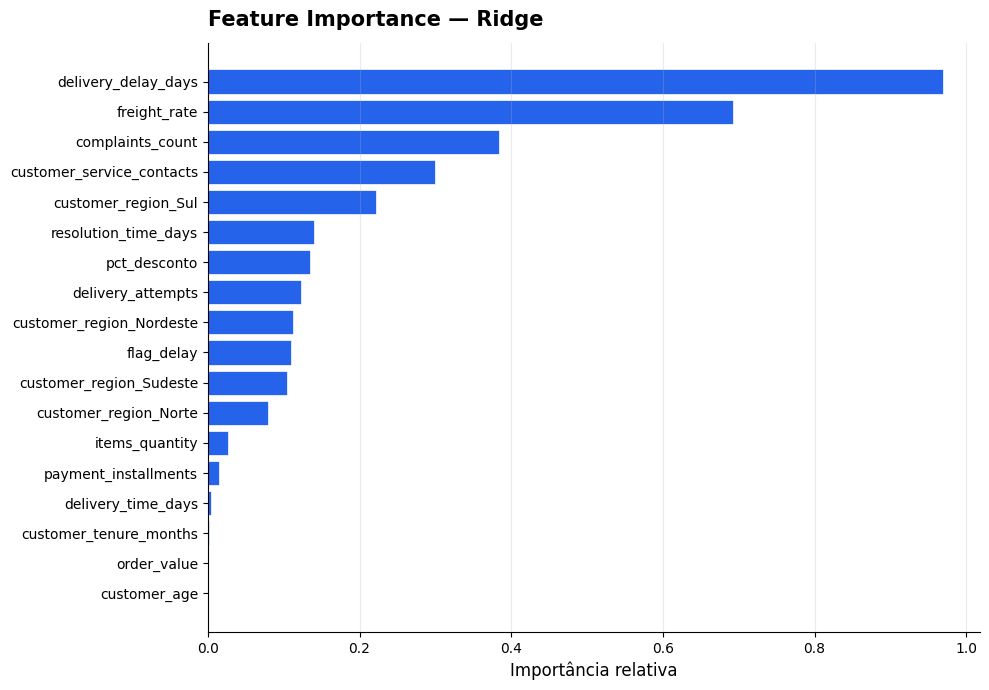


Top 5 features mais importantes:
                  Feature  Importância
      delivery_delay_days     0.969724
             freight_rate     0.692822
         complaints_count     0.383989
customer_service_contacts     0.299845
      customer_region_Sul     0.221979


In [18]:
if hasattr(melhor_modelo, "feature_importances_"):
    importancias = melhor_modelo.feature_importances_
else:
    # Para modelos lineares: usa o valor absoluto dos coeficientes
    importancias = np.abs(melhor_modelo.coef_)

df_importancia = (
    pd.DataFrame({"Feature": X_train.columns, "Importância": importancias})
    .sort_values("Importância", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    df_importancia["Feature"],
    df_importancia["Importância"],
    color="#2563EB",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title(
    f"Feature Importance — {nome_melhor}",
    fontsize=15, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Importância relativa", fontsize=12)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("\nTop 5 features mais importantes:")
print(df_importancia.sort_values("Importância", ascending=False).head(5).to_string(index=False))

**Conclusões**

- As features de maior importância confirmam os achados da EDA: variáveis logísticas (`delivery_delay_days`, `flag_delay`) e de atendimento (`complaints_count`) lideram a explicação do NPS.
- Features sem associação identificada na análise exploratória apresentam importância baixa, validando as escolhas de modelagem.
- A feature importance é acionável para o negócio: as variáveis no topo da lista são os alvos prioritários de melhoria operacional.

#### 8.2. Classificação derivada do NPS previsto

In [19]:
def classificar_nps(score):
    """Classifica o score de NPS em Detrator, Neutro ou Promotor conforme a regra de mercado."""
    if score <= 6.0:
        return "Detrator"
    elif score <= 8.0:
        return "Neutro"
    else:
        return "Promotor"

y_pred_classe = np.vectorize(classificar_nps)(y_pred_melhor)
y_true_classe = np.vectorize(classificar_nps)(y_test.values)

print("Distribuição das classes reais no teste:")
print(pd.Series(y_true_classe).value_counts())
print("\nDistribuição das classes previstas no teste:")
print(pd.Series(y_pred_classe).value_counts())

Distribuição das classes reais no teste:
Detrator    370
Neutro       90
Promotor     40
Name: count, dtype: int64

Distribuição das classes previstas no teste:
Detrator    401
Neutro       91
Promotor      8
Name: count, dtype: int64


#### 8.3. Métricas de classificação

In [20]:
ordem_classes = ["Detrator", "Neutro", "Promotor"]

print(f"Relatório de Classificação — {nome_melhor}")
print("(classificação derivada da previsão contínua de NPS)\n")
print(classification_report(y_true_classe, y_pred_classe, labels=ordem_classes))

Relatório de Classificação — Ridge
(classificação derivada da previsão contínua de NPS)

              precision    recall  f1-score   support

    Detrator       0.86      0.93      0.89       370
      Neutro       0.44      0.44      0.44        90
    Promotor       0.62      0.12      0.21        40

    accuracy                           0.78       500
   macro avg       0.64      0.50      0.51       500
weighted avg       0.76      0.78      0.76       500



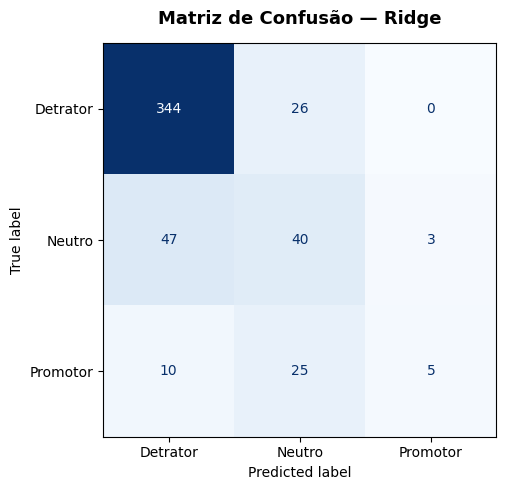

In [21]:
cm = confusion_matrix(y_true_classe, y_pred_classe, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordem_classes)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"Matriz de Confusão — {nome_melhor}",
    fontsize=13, fontweight="bold", pad=14,
)
plt.tight_layout()
plt.show()

**Conclusões**

- A métrica de negócio prioritária é o **recall na classe Detrator**: o custo de não identificar um detrator (falso negativo — previsto como Neutro ou Promotor sendo Detrator) é maior do que acionar preventivamente um cliente que seria Neutro.
- A classe Neutro tende a ser a mais difícil de classificar por estar no limiar entre as outras duas categorias.
- A matriz de confusão mostra os padrões de erro do modelo: confusões entre classes adjacentes (Detrator↔Neutro) são esperadas e menos custosas do que confusões entre extremos (Detrator↔Promotor).

### 9. Conclusões Gerais

**Estratégia adotada**

Optou-se por um modelo de regressão para prever o `nps_score` diretamente (escala 0–10), derivando a classificação Detrator/Neutro/Promotor a partir da nota prevista. Essa abordagem preserva a granularidade da informação e permite que um único modelo responda tanto à pergunta de regressão ("qual será a nota?") quanto à de classificação ("esse cliente será promotor ou detrator?").

**Principais achados**

- As variáveis logísticas e de atendimento (`delivery_delay_days`, `complaints_count`, `flag_delay`) dominam a explicação do NPS, confirmando os achados da EDA.
- Modelos não-lineares (Random Forest, Gradient Boosting) capturam interações entre variáveis que os modelos lineares não conseguem, tendendo a apresentar melhor RMSE no teste.
- O Lasso confirmou a irrelevância preditiva de várias features que a EDA já havia indicado sem associação direta com NPS.

**Como usar na prática**

Com esse modelo, a empresa pode, ao encerrar a jornada de entrega e atendimento de um pedido (antes de aplicar a pesquisa de NPS), calcular o score previsto para cada cliente. Clientes com score previsto ≤ 6 seriam priorizados para ações proativas de recuperação — contato de atendimento, compensação ou resolução antecipada de problemas — antes de se tornarem detratores declarados.

**Limitações**

- Os resultados são observacionais; associação não implica causalidade.
- O modelo foi treinado em uma amostra estática; performance pode variar com novos dados ao longo do tempo.
- A classe Neutro é sub-representada e tende a ser mais difícil de prever com precisão.